In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits 

In [3]:
output = fits.open("/dat/milic/MURaM_enhanced_network/che_full_499000_lwsynth_200.0.fits")
output.info()

Filename: /dat/milic/MURaM_enhanced_network/che_full_499000_lwsynth_200.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (1031, 1, 1024, 1024)   float64   
  1                1 ImageHDU         6   (1031,)   float64   
  2                1 ImageHDU         9   (401, 6, 1024, 1024)   float64   


In [4]:
spectrum = output[0].data

In [5]:
spectrum.shape

(1024, 1024, 1, 1031)

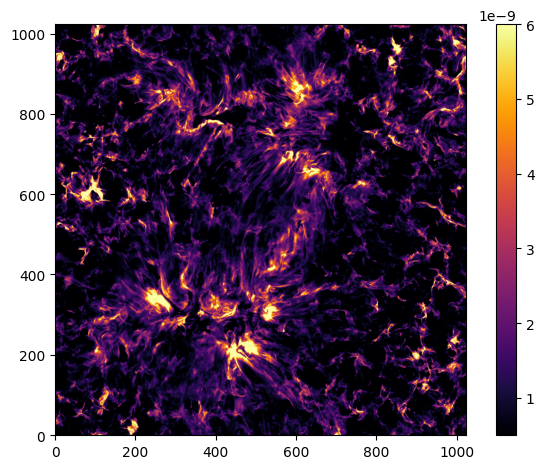

In [6]:
plt.imshow(spectrum[:,:,0,290].T, origin="lower", cmap='inferno', vmin=0.05E-8, vmax=0.6E-8)
plt.colorbar()
plt.tight_layout()
plt.savefig("linecore_image.png", dpi=300)

(0.0, 6e-09)

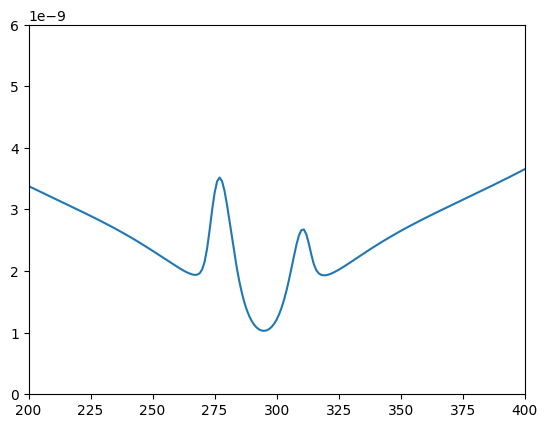

In [15]:
mean = np.mean(spectrum[:,:,0,:], axis=(0,1))
plt.plot(mean)
plt.xlim([200,400])
plt.ylim([0,6E-9])


In [18]:
pops = output[2].data
print(pops.shape)

(1024, 1024, 6, 401)


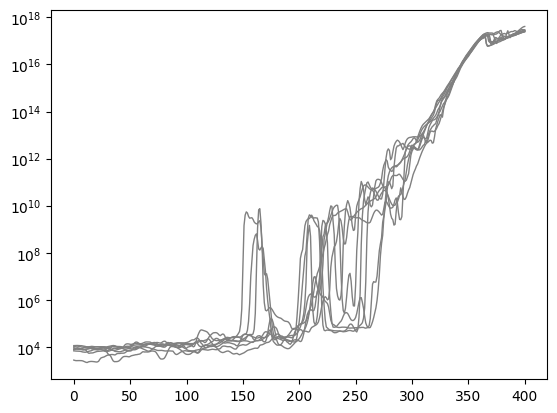

In [20]:
for i in range(0,8):
    for j in range(0,1):
        plt.semilogy(pops[i*10,j,0,:],linewidth=1.0, color='grey',alpha=1.0)

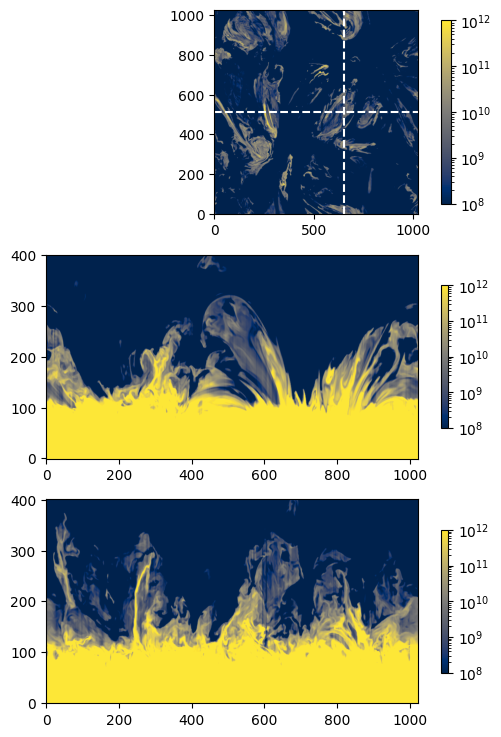

In [36]:
i_slice = 650
j_slice = 512

plt.figure(figsize=[6,9])

plt.subplot(311)
plt.imshow(pops[:,:,0,160].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12)
# Add a white line where the slice is taken
plt.axvline(i_slice, color='white', linestyle='--')
plt.axhline(j_slice, color='white', linestyle='--')
plt.colorbar(shrink=0.9)

plt.subplot(312)
plt.imshow(pops[i_slice,:,0,::-1].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12, aspect='auto')
plt.colorbar(shrink=0.7)

plt.subplot(313)
plt.imshow(pops[:,j_slice,0,::-1].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12, aspect='auto')
plt.colorbar(shrink=0.7)

In [37]:
# Let's cut this under a small angle and make use of the periodicity of the data to get a longer slice through the atmosphere
angle = 15  # degrees
angle_rad = np.radians(angle)

# starting point in x 
x_start = 0
y_start = 0

# these are native steps in x and y 
delta_x = 24 # in km
delta_y = 24 # in km

# We want a line that has given length:
line_length_km = 2E5  # in km

n_steps = int(line_length_km / delta_x)
print("number of steps is: ", n_steps)

number of steps is:  8333


In [ ]:
# Get the coordinates of this steps: 
x_coords = x_start + (np.arange(n_steps) + 0.5) * delta_x * np.cos(angle_rad)
y_coords = y_start + (np.arange(n_steps) + 0.5) * delta_y * np.sin(angle_rad)

In [ ]:
x_coords_in_box = x_coords % (pops.shape[0]*delta_x)
y_coords_in_box = y_coords % (pops.shape[1]*delta_y) 

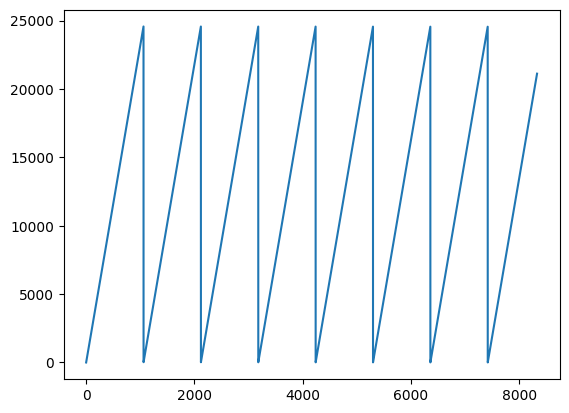

In [43]:
plt.plot(x_coords_in_box)

In [1]:
# For a given z slice, we can now interpolate the population values along this line.
z_slice = 160  # for example, the first z slice

from scipy.interpolate import RegularGridInterpolator
# Interpolator is 2D , and it takes values from the box and then interpolates onto the "long" line, that is folded back into the box.
# Create an interpolator for the population data
interpolator = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), pops[:,:,0,z_slice], bounds_error=False, fill_value=np.nan)
# Interpolate along the line
pop_along_line = interpolator(np.array([x_coords_in_box, y_coords_in_box]).T)

NameError: name 'pops' is not defined

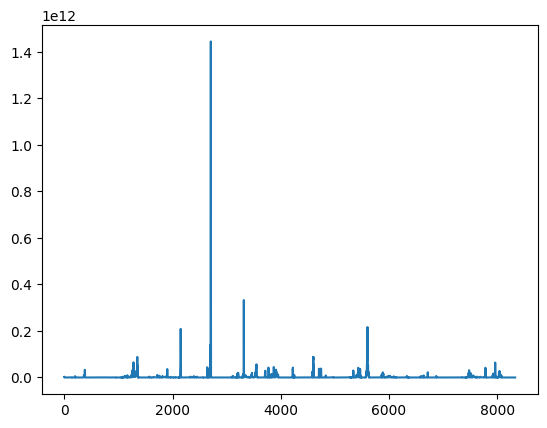

In [45]:
plt.plot(pop_along_line)

In [46]:
np.sum(np.isnan(pop_along_line))

np.int64(14)